In [31]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker

In [32]:
# Settingan agar baris tidak dibatasi tampilannya saat print
pd.set_option('display.max_rows', None)

# Settingan agar kolom tidak dibatasi tampilannya saat print
pd.set_option('display.max_columns', None)

# Seetingan agar lebar kolom tidak terpotong
pd.set_option('display.width', None)

In [33]:
# Mengatur tema visual grafik
sns.set_theme(style="whitegrid")

In [34]:
# Memuat dataset
file_path = '../data/Result_Data_Query/01_ inventory_aging_data.csv'
df_inventory = pd.read_csv(file_path)

In [35]:
# Melihat struktur dataset
df_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_name      130 non-null    object 
 1   category_name     130 non-null    object 
 2   subcategory_name  130 non-null    object 
 3   avg_stockpiling   130 non-null    float64
 4   total_sell        130 non-null    int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 5.2+ KB


In [36]:
# Print hasil memuat dataset dan sorting ascending berdasarkan kolom "df_inventory"
df_inventory.sort_values(by="avg_stockpiling", ascending=False)

,product_name,category_name,subcategory_name,avg_stockpiling,total_sell
0,"Touring-3000 Blue, 58",Bikes,Touring Bikes,4824.771930,57
1,"Road-650 Black, 62",Bikes,Road Bikes,4823.900000,50
2,"Road-650 Red, 60",Bikes,Road Bikes,4823.846154,39
3,"Touring-3000 Yellow, 44",Bikes,Touring Bikes,4823.474576,59
4,"Mountain-100 Silver, 48",Bikes,Mountain Bikes,4822.909091,22
5,"Touring-3000 Blue, 50",Bikes,Touring Bikes,4821.375000,48
6,"Road-650 Red, 52",Bikes,Road Bikes,4820.333333,51
7,"Mountain-500 Silver, 42",Bikes,Mountain Bikes,4820.244444,45
8,"Touring-2000 Blue, 54",Bikes,Touring Bikes,4819.895349,86
9,"Mountain-500 Black, 42",Bikes,Mountain Bikes,4819.875000,48


In [37]:
# Melihat statistik deskriptif dari kolom Waktu Mengendap avg_stockpiling
display(df_inventory['avg_stockpiling'].describe())

count     130.000000
mean     4815.998830
std         3.130142
min      4802.577778
25%      4814.677950
50%      4816.048530
75%      4817.502139
max      4824.771930
Name: avg_stockpiling, dtype: float64

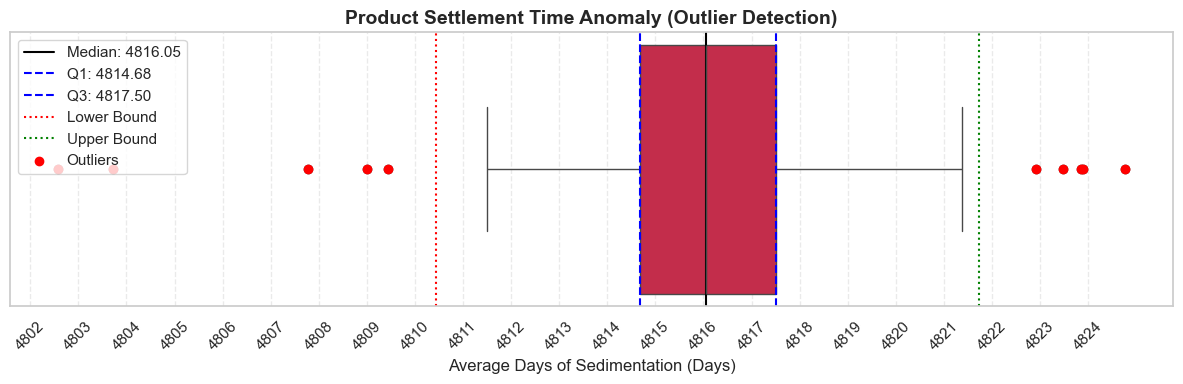

In [38]:
# ==========================================
# FASE 1 : Pemeriksaan Kesehatan Data (Deteksi Anomali / Outlier)
# ==========================================

# Visualisasi boxplot untuk mendetekasi outlier / anomali
# plt.figure(figsize=(10,3))
# sns.boxplot(x=df_inventory['avg_stockpiling'],color='crimson')
# plt.title('Product Settlement Time Anomaly (Outlier) Detection', fontsize=14, fontweight='bold')
# plt.xlabel('Average Days of Sedimentation (Days)', fontsize=12)

# plt.show()

plt.figure(figsize=(12,4))

# 🔹 Boxplot utama
sns.boxplot(x=df_inventory['avg_stockpiling'], color='crimson')

# 🔹 Hitung statistik
Q1 = df_inventory['avg_stockpiling'].quantile(0.25)
median = df_inventory['avg_stockpiling'].median()
Q3 = df_inventory['avg_stockpiling'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 🔹 Tambahkan garis referensi
plt.axvline(median, color='black', linestyle='-', 
            label=f'Median: {median:.2f}')

plt.axvline(Q1, color='blue', linestyle='--', 
            label=f'Q1: {Q1:.2f}')

plt.axvline(Q3, color='blue', linestyle='--', 
            label=f'Q3: {Q3:.2f}')

plt.axvline(lower_bound, color='red', linestyle=':', 
            label='Lower Bound')

plt.axvline(upper_bound, color='green', linestyle=':', 
            label='Upper Bound')

# 🔹 Highlight outlier
outliers = df_inventory[
    (df_inventory['avg_stockpiling'] < lower_bound) |
    (df_inventory['avg_stockpiling'] > upper_bound)
]

plt.scatter(outliers['avg_stockpiling'], 
            [0]*len(outliers),
            color='red', label='Outliers', zorder=3) 

# 🔹 Perbaiki axis (ini solve masalah kamu)
xmin = df_inventory['avg_stockpiling'].min()
xmax = df_inventory['avg_stockpiling'].max()

plt.xlim(xmin - 1, xmax + 1)
plt.xticks(np.arange(int(xmin), int(xmax)+1, 1), rotation=45)

# 🔹 Tambahkan grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

# 🔹 Judul & label
plt.title('Product Settlement Time Anomaly (Outlier Detection)',
          fontsize=14, fontweight='bold')

plt.xlabel('Average Days of Sedimentation (Days)', fontsize=12)

# 🔹 Legend
plt.legend()

# Merapihkan tata letak agar tidak terpotong
plt.tight_layout()

# Menyimpan grafik sebagai gambar PNG di Folder Proyek
plt.savefig('../dashboards/python/outlier_detection.png', dpi=300)

plt.show()


HASIL UJI KORELASI PEARSON
Nilai Korelasi (Waktu Inap vs Tingkat Retur) : 0.0010



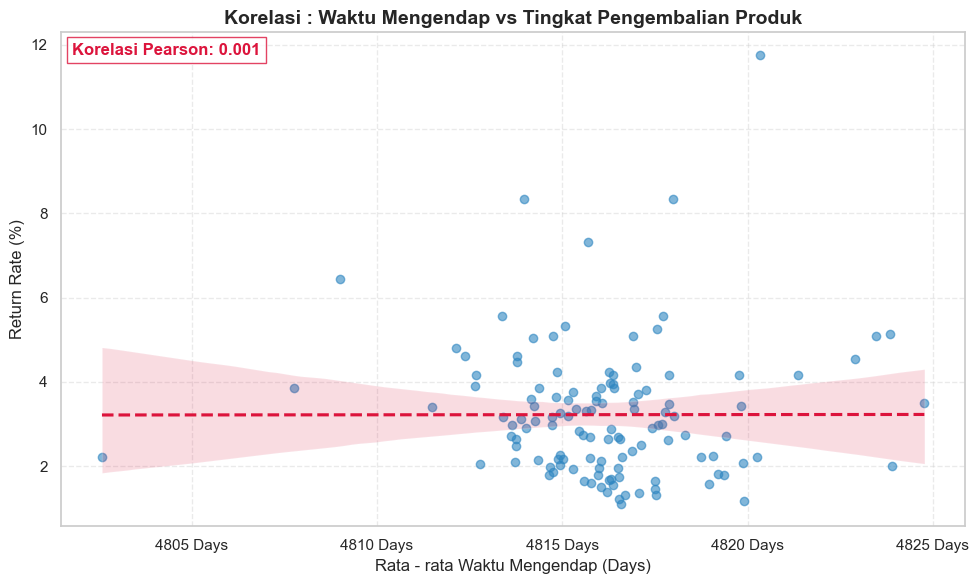

In [39]:
# ==========================================
# FASE 2: UJI KORELASI (RCA)
# ==========================================

# Memuat data Return Rate
file_return = '../data/Result_Data_Query/02_product_return_rate.csv'
df_return = pd.read_csv(file_return)

# Menggabungkan (Merge) kedua dataset berdasarkan nama produk
# Menggunakan Inner Join agar hanya menganalisis produk yang ada di kedua tabel
df_merged = pd.merge(df_inventory, df_return, on='product_name', how='inner')

# Menghitung Korelasi Pearson (seberapa kuat hubungan linier antara dua variabel numerik)
korelasi = df_merged['avg_stockpiling'].corr(df_merged['return_rate'])
print(f"HASIL UJI KORELASI PEARSON")
print(f"Nilai Korelasi (Waktu Inap vs Tingkat Retur) : {korelasi:.4f}\n")

# Visualisasi Scatter Plot
plt.figure(figsize=(10,6))
sns.regplot(
x='avg_stockpiling',
y='return_rate',
data=df_merged,
scatter_kws={'alpha':0.6, 'color':'#2E86C1'},
line_kws={'color':'crimson','linestyle':'--'}
)

plt.title('Korelasi : Waktu Mengendap vs Tingkat Pengembalian Produk', fontsize=14, fontweight='bold')
plt.xlabel('Rata - rata Waktu Mengendap (Days)',fontsize=12)
# Menambahkan string Days di belakang label nilai sumbu x
plt.gca().xaxis.set_major_formatter(
mticker.FuncFormatter(lambda x, _: f'{int(x)} Days')
  )
plt.ylabel('Return Rate (%)', fontsize=12)
plt.grid(True,linestyle='--', alpha=0.4)

# Menampilkan teks korelasi di dalam grafik
plt.text(
# Min & Max pada x dan y untuk menentukan posisi teks korelasi
x=df_merged['avg_stockpiling'].min()-0.80,
y=df_merged['return_rate'].max(),
s=f'Korelasi Pearson: {korelasi:.3f}',
fontsize=12,fontweight='bold',color='crimson',
bbox=dict(facecolor='white', alpha=0.8, edgecolor='crimson')
  )

# Merapihkan tata letak agar tidak terpotong
plt.tight_layout()

# Menyimpan grafik sebagai gambar PNG di Folder Proyek
plt.savefig('../dashboards/python/Correlation_stockpiling_&_ReturnRate.png', dpi=300)

plt.show()